In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
RAW_PATH = Path("../data/raw/online_retail_II.xlsx")

sheets = pd.read_excel(RAW_PATH, sheet_name=None, engine="openpyxl")
print(list(sheets.keys()))

df = pd.concat(
    [sheet_df.assign(source_sheet=name) for name, sheet_df in sheets.items()],
    ignore_index=True,
)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
print(df.shape)
df.head()

['Year 2009-2010', 'Year 2010-2011']
(1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   Invoice       1067371 non-null  object        
 1   StockCode     1067371 non-null  object        
 2   Description   1062989 non-null  object        
 3   Quantity      1067371 non-null  int64         
 4   InvoiceDate   1067371 non-null  datetime64[ns]
 5   Price         1067371 non-null  float64       
 6   Customer_ID   824364 non-null   float64       
 7   Country       1067371 non-null  object        
 8   source_sheet  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [4]:
# Missing values per column — how bad is the Customer_ID gap?
df.isna().sum()

Invoice              0
StockCode            0
Description       4382
Quantity             0
InvoiceDate          0
Price                0
Customer_ID     243007
Country              0
source_sheet         0
dtype: int64

In [5]:
df.isna().mean() * 100  # as a percentage

Invoice          0.000000
StockCode        0.000000
Description      0.410541
Quantity         0.000000
InvoiceDate      0.000000
Price            0.000000
Customer_ID     22.766873
Country          0.000000
source_sheet     0.000000
dtype: float64

In [ ]:

df["line_total"] = df["Quantity"] * df["Price"]

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(6, 3))
missing_pct.plot(kind="barh", ax=ax, color="#c44e52")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()

In [6]:
# Invoice column: what non-numeric prefixes exist? This is how you find cancellations,
# not by assuming "C" is the only one.
df["Invoice"] = df["Invoice"].astype(str)
df["invoice_first_char"] = df["Invoice"].str[0]
df["invoice_first_char"].value_counts()

invoice_first_char
5    939382
4    108489
C     19494
A         6
Name: count, dtype: int64

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
df["invoice_first_char"].value_counts().plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_title("Invoice prefix counts (5/4 = normal, C = cancelled, A = bad-debt adj)")
ax.set_xlabel("First character of Invoice")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()

In [7]:
# Look at a sample of rows for each unusual prefix you find above
df[df["invoice_first_char"] == "C"].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,source_sheet,invoice_first_char
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,Year 2009-2010,C
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,Year 2009-2010,C
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,Year 2009-2010,C
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,Year 2009-2010,C
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,Year 2009-2010,C


In [8]:
# Quantity: distribution, and how many are negative/zero
df["Quantity"].describe()

count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

In [9]:
(df["Quantity"] <= 0).sum(), (df["Quantity"] <= 0).mean() * 100

(np.int64(22950), np.float64(2.1501427338760375))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.loc[df["Quantity"] > 0, "Quantity"].clip(upper=200).hist(bins=60, ax=axes[0], color="#55a868")
axes[0].set_title("Quantity (positive only, clipped at 200)")
axes[0].set_xlabel("Quantity")

df.loc[df["Price"] > 0, "Price"].clip(upper=50).hist(bins=60, ax=axes[1], color="#dd8452")
axes[1].set_title("Price (positive only, clipped at £50)")
axes[1].set_xlabel("Price (£)")

plt.tight_layout()
plt.show()

In [10]:
# StockCode: this is the important one. Real product codes in this dataset are
# mostly 5-digit numeric strings. Look at what DOESN'T fit that pattern, 
# these are candidates for "not a real product" (fees, postage, adjustments, etc.)
df["StockCode"] = df["StockCode"].astype(str)
non_numeric_codes = df[~df["StockCode"].str.match(r"^\d{5}$")]
non_numeric_codes["StockCode"].value_counts().head(30)

StockCode
85123A     5829
85099B     4216
POST       2122
82494L     2108
85099C     1952
85099F     1916
84970S     1477
DOT        1446
M          1421
84029E     1279
47591D     1184
84997D     1146
84029G     1124
84970L     1119
15056N     1078
84997B     1066
84997C      994
85014B      933
15056BL     923
47590B      906
84406B      904
85049E      897
47566B      804
84520B      756
84596B      753
47559B      745
85049A      728
85014A      710
47590A      709
84032A      702
Name: count, dtype: int64

In [11]:
# For each unusual code above, check what Description says, that tells you
# whether it's a real product with an odd code, or genuinely not a sale.
for code in non_numeric_codes["StockCode"].value_counts().head(15).index:
    desc = df.loc[df["StockCode"] == code, "Description"].mode()
    print(code, "->", desc.values[:1])

85123A -> ['WHITE HANGING HEART T-LIGHT HOLDER']
85099B -> ['JUMBO BAG RED RETROSPOT']
POST -> ['POSTAGE']
82494L -> ['WOODEN FRAME ANTIQUE WHITE ']
85099C -> ['JUMBO  BAG BAROQUE BLACK WHITE']
85099F -> ['JUMBO BAG STRAWBERRY']
84970S -> ['HANGING HEART ZINC T-LIGHT HOLDER']
DOT -> ['DOTCOM POSTAGE']
M -> ['Manual']
84029E -> ['RED WOOLLY HOTTIE WHITE HEART.']
47591D -> ['PINK FAIRY CAKE CHILDRENS APRON']
84997D -> ['PINK 3 PIECE MINI DOTS CUTLERY SET']
84029G -> ['KNITTED UNION FLAG HOT WATER BOTTLE']
84970L -> ['SINGLE HEART ZINC T-LIGHT HOLDER']
15056N -> ['EDWARDIAN PARASOL NATURAL']


In [ ]:
is_standard = df["StockCode"].str.match(r"^\d{5}$") | df["StockCode"].str.match(r"^\d{5}[A-Za-z]$")
non_standard = df[~is_standard]

fig, ax = plt.subplots(figsize=(6, 6))
non_standard["StockCode"].value_counts().head(20).plot(kind="barh", ax=ax, color="#8172b2")
ax.invert_yaxis()
ax.set_title("Top 20 non-standard StockCodes by row count")
ax.set_xlabel("Row count")
plt.tight_layout()
plt.show()

In [12]:
# Duplicate rows
df.duplicated().sum()

np.int64(12133)

In [13]:
# Country spread — useful context for the international/domestic feature later
df["Country"].value_counts()

Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
Poland                     535
USA                        535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


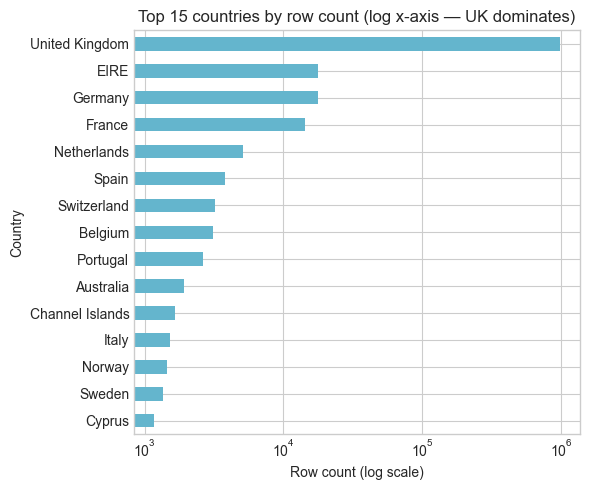

Rows with Country == 'Unspecified': 756


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
df["Country"].value_counts().head(15).plot(kind="barh", ax=ax, color="#64b5cd", logx=True)
ax.invert_yaxis()
ax.set_title("Top 15 countries by row count (log x-axis — UK dominates)")
ax.set_xlabel("Row count (log scale)")
plt.tight_layout()
plt.show()

print("Rows with Country == 'Unspecified':", (df["Country"] == "Unspecified").sum())

### Revenue over time

Note: December 2011 is a partial month in this dataset (only through the 9th), so its bar will look artificially low, that's a data cutoff, not a real sales drop.

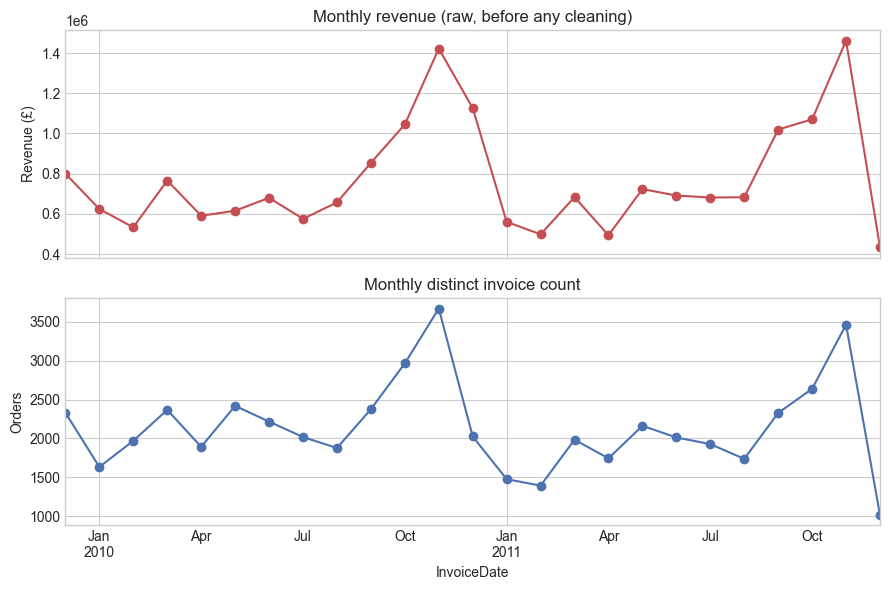

In [ ]:
monthly = df.set_index("InvoiceDate").resample("MS").agg(
    revenue=("line_total", "sum"),
    orders=("Invoice", "nunique"),
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

monthly["revenue"].plot(ax=axes[0], marker="o", color="#c44e52")
axes[0].set_title("Monthly revenue (raw, before any cleaning)")
axes[0].set_ylabel("Revenue (£)")

monthly["orders"].plot(ax=axes[1], marker="o", color="#4c72b0")
axes[1].set_title("Monthly distinct invoice count")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

### Revenue concentration (why we need density-based clustering, not just K-Means)

If a handful of customers account for a huge share of revenue, K-Means will be forced to either give them their own cluster (fine) or awkwardly average them into a "high spender" segment that dilutes the real signal (bad). DBSCAN can instead flag them as noise/outliers, worth checking how concentrated revenue actually is here.

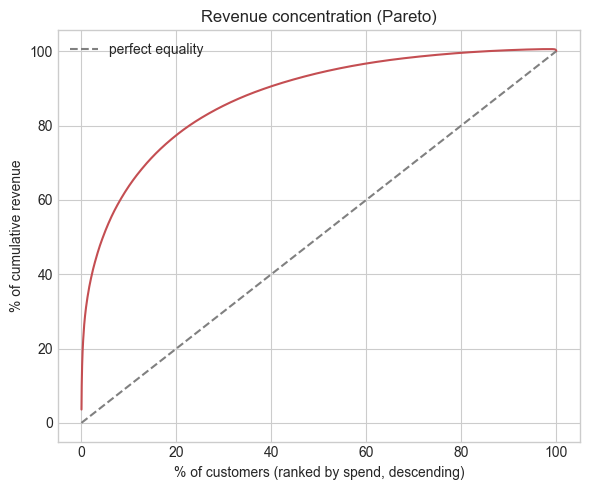

Top 1% of customers (59) generate 31.3% of revenue
Top 10% of customers (594) generate 63.7% of revenue


In [ ]:
import numpy as np

# Rough cut just for this exploration chart, excludes missing Customer_ID,
# doesn't apply the full cleaning pipeline (that happens in notebook 01_data_cleaning)
rev_by_cust = (
    df.dropna(subset=["Customer_ID"])
      .groupby("Customer_ID")["line_total"].sum()
      .sort_values(ascending=False)
)
cum_pct_revenue = rev_by_cust.cumsum() / rev_by_cust.sum() * 100
cum_pct_customers = np.arange(1, len(rev_by_cust) + 1) / len(rev_by_cust) * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(cum_pct_customers, cum_pct_revenue, color="#c44e52")
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", label="perfect equality")
ax.set_xlabel("% of customers (ranked by spend, descending)")
ax.set_ylabel("% of cumulative revenue")
ax.set_title("Revenue concentration (Pareto)")
ax.legend()
plt.tight_layout()
plt.show()

top1_idx = int(len(rev_by_cust) * 0.01)
top10_idx = int(len(rev_by_cust) * 0.10)
print(f"Top 1% of customers ({top1_idx}) generate {cum_pct_revenue.iloc[top1_idx-1]:.1f}% of revenue")
print(f"Top 10% of customers ({top10_idx}) generate {cum_pct_revenue.iloc[top10_idx-1]:.1f}% of revenue")

## Summary of findings

- **1,067,371 raw rows**, 22.77% missing `Customer_ID`, will be dropped since we can't attribute those to a customer for segmentation.
- **19,494 cancelled orders** (`Invoice` starts with "C"), plus 6 "bad debt adjustment" rows (`Invoice` starts with "A") that have no `Customer_ID` anyway.
- **2.15%** of rows have non-positive `Quantity`, **0.58%** have non-positive `Price`, inspected and confirmed these are returns/losses/adjustments, not real sales.
- Non-standard `StockCode` values are a small tail (~0.7% of rows) and mix real products (e.g. `15056BL` = Edwardian Parasol) with genuine non-products (`POST`, `DOT`, `M`, `BANK CHARGES`, etc.), decided case by case in the cleaning notebook, not by a blanket regex drop.
- **12,133 exact duplicate rows**, worth dropping.
- **UK dominates** at ~92% of rows; Germany, EIRE, and France are the next largest, supports an `is_international` flag as a feature rather than full country dummies.
- **Seasonality**: strong November revenue spike each year (holiday shopping ahead of Christmas shipping cutoffs); December is muted partly because 2011's December is cut off mid-month in this dataset.
- **Revenue is highly concentrated**: top 1% of customers generate ~31% of revenue, top 10% generate ~64%. This is the core justification for comparing DBSCAN against K-Means, a few whale customers shouldn't be forced into an arbitrary segment.